In [1]:
import pandas as pd
import numpy as np

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestRegressor

from sklearn.cluster import KMeans

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

In [2]:
data = pd.read_csv("C:/Users/HP/Downloads/E-commerce_Delivery_Shipping_Data_2026.csv")



# Dataset Preview

In [8]:
data.head()

,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,...,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
0,ORD-000001,2026-11-15,CUS-002353,Small Business,Tokyo,Japan,WH-004,Toronto,Home & Kitchen,8.23,...,Large,Digital Wallet,Normal,Snow,3,Yes,Late Delivery,2,25.1,Delivered
1,ORD-000002,2026-04-08,CUS-003258,Consumer,Vancouver,Canada,WH-007,Paris,Beauty,0.10,...,Small,Debit Card,Normal,Cloudy,5,No,NaN,1,25.9,Delivered
2,ORD-000003,2026-01-05,CUS-001221,Consumer,Houston,United States,WH-005,London,Home & Kitchen,5.51,...,Large,Debit Card,Low,Snow,4,Yes,Product Defect,1,31.5,Delivered
3,ORD-000004,2026-05-29,CUS-001717,Small Business,Delhi,India,WH-002,Los Angeles,Grocery,3.75,...,Large,Debit Card,Normal,Snow,3,No,NaN,1,12.6,In Transit
4,ORD-000005,2026-02-22,CUS-000716,Small Business,Nagoya,Japan,WH-006,Berlin,Beauty,0.10,...,Small,Credit Card,Normal,Storm,2,No,NaN,1,24.9,Delivered


In [13]:
data.column

Index(['order_id', 'order_date', 'customer_id', 'customer_segment',
       'customer_city', 'customer_country', 'warehouse_id', 'warehouse_city',
       'product_category', 'product_weight_kg', 'order_value_usd',
       'shipping_method', 'carrier', 'distance_km', 'promised_delivery_days',
       'actual_delivery_days', 'delivery_status', 'late_delivery',
       'delivery_delay_days', 'shipping_cost_usd', 'package_size',
       'payment_method', 'order_priority', 'weather_condition',
       'customer_rating', 'return_requested', 'return_reason',
       'delivery_attempts', 'warehouse_processing_hours', 'tracking_status'],
      dtype='object')

In [8]:
data.tail()

,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,...,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
49995,ORD-049996,2026-09-05,CUS-004163,Small Business,Leipzig,Germany,WH-001,New York,Electronics,0.86,...,Medium,Digital Wallet,High,Cloudy,4,No,NaN,2,9.1,Delivered
49996,ORD-049997,2026-12-07,CUS-004322,Consumer,London,United Kingdom,WH-005,London,Toys,0.27,...,Small,Cash on Delivery,Normal,Cloudy,4,No,NaN,1,8.9,Delivered
49997,ORD-049998,2026-11-14,CUS-000699,Enterprise,San Diego,United States,WH-001,New York,Automotive,7.76,...,Oversized,Credit Card,Low,Clear,3,Yes,Late Delivery,1,5.5,Delivered
49998,ORD-049999,2026-09-02,CUS-004696,Consumer,London,United Kingdom,WH-007,Paris,Books,1.10,...,Medium,PayPal,Low,Snow,3,No,NaN,1,45.4,Delivered
49999,ORD-050000,2026-04-11,CUS-000955,Consumer,Sharjah,United Arab Emirates,WH-001,New York,Fashion,1.36,...,Large,Digital Wallet,High,Cloudy,2,No,NaN,1,11.4,Delivered


# dataset information

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   order_id                    50000 non-null  object 
 1   order_date                  50000 non-null  object 
 2   customer_id                 50000 non-null  object 
 3   customer_segment            50000 non-null  object 
 4   customer_city               50000 non-null  object 
 5   customer_country            50000 non-null  object 
 6   warehouse_id                50000 non-null  object 
 7   warehouse_city              50000 non-null  object 
 8   product_category            50000 non-null  object 
 9   product_weight_kg           50000 non-null  float64
 10  order_value_usd             50000 non-null  float64
 11  shipping_method             50000 non-null  object 
 12  carrier                     50000 non-null  object 
 13  distance_km                 500

In [13]:
print("number of rows:",data.shape[0])
print("number of columns:",data.shape[1])

number of rows: 50000
number of columns: 30


In [14]:
data.sample(5, random_state=42)

,order_id,order_date,customer_id,customer_segment,customer_city,customer_country,warehouse_id,warehouse_city,product_category,product_weight_kg,...,package_size,payment_method,order_priority,weather_condition,customer_rating,return_requested,return_reason,delivery_attempts,warehouse_processing_hours,tracking_status
33553,ORD-033554,2026-07-04,CUS-004170,Consumer,Austin,United States,WH-001,New York,Beauty,0.43,...,Small,Bank Transfer,Low,Rain,2,Yes,Damaged Package,1,7.9,Delivered
9427,ORD-009428,2026-03-27,CUS-002411,Consumer,Kolkata,India,WH-002,Los Angeles,Health & Personal Care,0.10,...,Small,PayPal,Normal,Extreme Heat,3,No,NaN,2,20.7,Delivered
199,ORD-000200,2026-11-11,CUS-002268,Consumer,Turin,Italy,WH-003,Chicago,Fashion,0.72,...,Medium,PayPal,Normal,Rain,4,No,NaN,1,13.2,Delivered
12447,ORD-012448,2026-11-08,CUS-005575,Enterprise,Cologne,Germany,WH-005,London,Office Supplies,0.92,...,Medium,Debit Card,Normal,Cloudy,5,No,NaN,1,10.0,Delivered
39489,ORD-039490,2026-04-01,CUS-005057,Small Business,Chicago,United States,WH-005,London,Toys,0.80,...,Medium,Debit Card,High,Clear,3,Yes,Product Defect,2,9.1,Delivered


# missing values

In [18]:
missing_values = data.isnull().sum()

missing_values = (
    missing_values[
        missing_values > 0
    ]
    .sort_values(ascending=False)
)

print(missing_values)


return_reason    41375
dtype: int64


# Duplicate check

In [19]:
duplicate_count = data.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


# Data Quality Summary

In [22]:
quality_summary = pd.DataFrame({
    "Column": data.columns,
    "Data Type": data.dtypes.astype(str),
    "Missing Values": data.isnull().sum().values,
    "Unique Values": data.nunique().values
})

quality_summary

,Column,Data Type,Missing Values,Unique Values
order_id,order_id,object,0,50000
order_date,order_date,object,0,365
customer_id,customer_id,object,0,6348
customer_segment,customer_segment,object,0,4
customer_city,customer_city,object,0,99
customer_country,customer_country,object,0,17
warehouse_id,warehouse_id,object,0,10
warehouse_city,warehouse_city,object,0,10
product_category,product_category,object,0,12
product_weight_kg,product_weight_kg,float64,0,2075


# Buissness problem

In [ ]:
# Buissness problem
E-commerce logistics operations involve multiple factors such as
shipping cost, delivery time, warehouse operations, carrier performance,
and customer satisfaction.

The objective of this project is to analyze these factors and develop
a data-driven framework that can help logistics teams monitor delivery
performance, identify operational segments, estimate delivery delays,
and evaluate shipping-cost scenarios

# KPIs

In [ ]:
## Key Performance Indicators (KPIs)

The following KPIs are used to evaluate logistics performance:

1. Fulfillment Rate
2. Average Delivery Delay
3. Average Shipping Cost
4. Average Customer Rating

In [23]:
fulfillment_rate = (
    data["delivery_status"]
    .eq("Delivered")
    .mean() * 100
)

avg_delay = data["delivery_delay_days"].mean()

avg_shipping_cost = data["shipping_cost_usd"].mean()

avg_rating = data["customer_rating"].mean()

print(f"Fulfillment Rate: {fulfillment_rate:.2f}%")
print(f"Average Delivery Delay: {avg_delay:.2f} days")
print(f"Average Shipping Cost: ${avg_shipping_cost:.2f}")
print(f"Average Customer Rating: {avg_rating:.2f}/5")

Fulfillment Rate: 88.37%
Average Delivery Delay: 1.28 days
Average Shipping Cost: $120.52
Average Customer Rating: 3.37/5


# KPIs Dashboard

In [25]:
kpi_data = pd.DataFrame({
    "KPI": [
        "Fulfillment Rate",
        "Average Delay",
        "Average Shipping Cost",
        "Average Customer Rating"
    ],
    "Value": [
        fulfillment_rate,
        avg_delay,
        avg_shipping_cost,
        avg_rating
    ]
})

kpi_data

,KPI,Value
0,Fulfillment Rate,88.368000
1,Average Delay,1.281080
2,Average Shipping Cost,120.515538
3,Average Customer Rating,3.371840


# Delevery Status Analysis

In [29]:
status_counts = (
    data["delivery_status"]
    .value_counts()
    .reset_index()
)

status_counts.columns = [
    "Delivery Status",
    "Orders"
]

status_counts


,Delivery Status,Orders
0,Delivered,44184
1,In Transit,4007
2,Delayed,1806
3,Failed Delivery,3


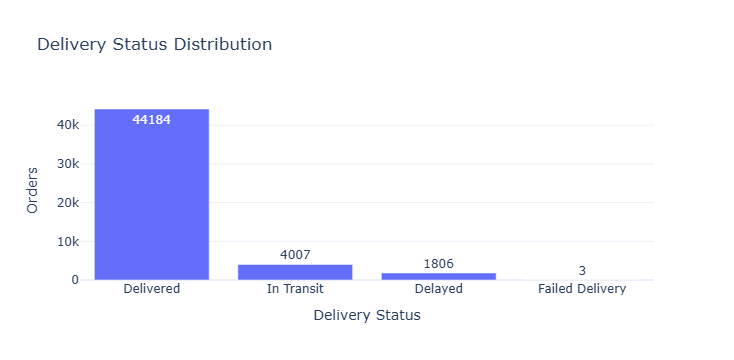

In [32]:
fig = px.bar(
    status_counts,
    x="Delivery Status",
    y="Orders",
    title="Delivery Status Distribution",
    text="Orders"
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

# Delevary Delay Distrubution

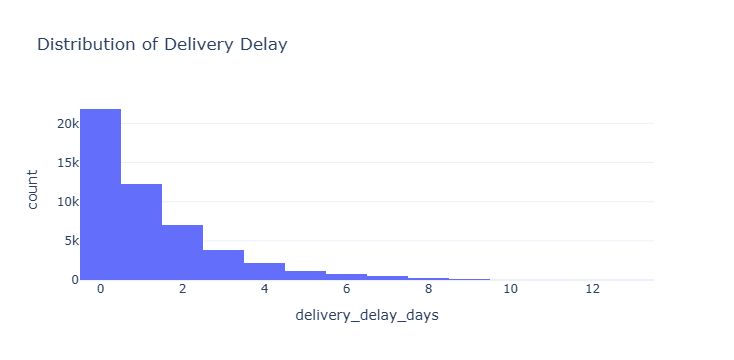

In [33]:
fig = px.histogram(
    data,
    x="delivery_delay_days",
    nbins=20,
    title="Distribution of Delivery Delay"
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

# Shiping Cost vs Delay

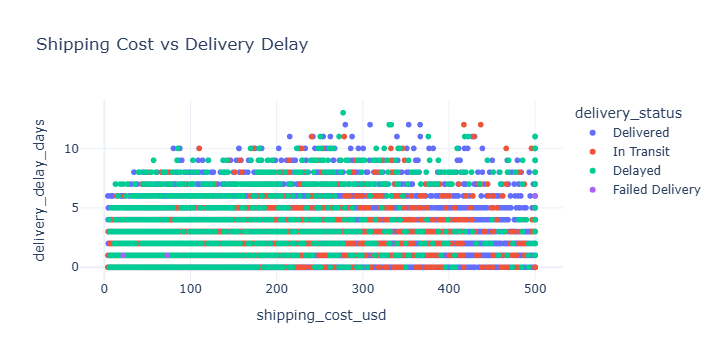

In [40]:
fig = px.scatter(
    data,
    x="shipping_cost_usd",
    y="delivery_delay_days",
    color="delivery_status",
    title="Shipping Cost vs Delivery Delay",
    hover_data=[
        "carrier",
        "warehouse_city",
        "weather_condition"
    ]
)

fig.update_layout(
    template="plotly_white"
)

fig.show()

# Regression

In [ ]:
## Machine Learning — Delivery Delay Prediction

### Objective

Predict the number of delivery-delay days using available order,
shipping, warehouse, carrier, and other logistics features.

### Model

Random Forest Regressor

# Clustering

In [ ]:
## Customer / Order Segmentation Using K-Means

K-Means clustering is used to identify groups of orders with similar
shipping cost, delivery delay, and customer-rating characteristics.

# Optimization

In [ ]:
## Shipping Cost Optimization

A scenario-based optimization approach is used to examine shipping
cost under a delivery-time constraint.

The objective is to understand the cost level associated with orders
that meet a selected delivery-delay target.

# Final Business Insights

In [ ]:
## Business Insights

Based on the analysis:

- Delivery performance can be monitored using fulfillment and delay KPIs.
- Shipping cost and delivery delay should be evaluated together.
- Regression can support delivery-delay estimation.
- Clustering can identify different operational order segments.
- Cost-versus-service scenarios can support logistics planning.

# Regression: Predict Delivery Delay


In [6]:
# Regression: Predict Delivery Delay

target = "delivery_delay_days"

exclude = [
    "delivery_delay_days",
    "delivery_status",
    "customer_rating"
]

X = data.drop(
    columns=[c for c in exclude if c in data.columns]
)

y = pd.to_numeric(
    data[target],
    errors="coerce"
)

# Remove rows where target is missing
valid = y.notna()

X = X.loc[valid].copy()
y = y.loc[valid]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (50000, 27)
y shape: (50000,)


In [7]:
num_cols = X.select_dtypes(
    include=np.number
).columns.tolist()

cat_cols = X.select_dtypes(
    exclude=np.number
).columns.tolist()

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)

Numeric columns: ['product_weight_kg', 'order_value_usd', 'distance_km', 'promised_delivery_days', 'actual_delivery_days', 'shipping_cost_usd', 'delivery_attempts', 'warehouse_processing_hours']
Categorical columns: ['order_id', 'order_date', 'customer_id', 'customer_segment', 'customer_city', 'customer_country', 'warehouse_id', 'warehouse_city', 'product_category', 'shipping_method', 'carrier', 'late_delivery', 'package_size', 'payment_method', 'order_priority', 'weather_condition', 'return_requested', 'return_reason', 'tracking_status']


In [8]:
preprocess = ColumnTransformer([
    (
        "num",
        SimpleImputer(strategy="median"),
        num_cols
    ),
    (
        "cat",
        Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]),
        cat_cols
    )
])

In [9]:
model = Pipeline([
    ("prep", preprocess),
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
])

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 40000
Testing rows: 10000


In [12]:
model.fit(X_train, y_train)

print("Regression model trained successfully!")

Regression model trained successfully!


In [13]:
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print(f"MAE: {mae:.3f} days")
print(f"R² Score: {r2:.3f}")

MAE: 0.004 days
R² Score: 0.999


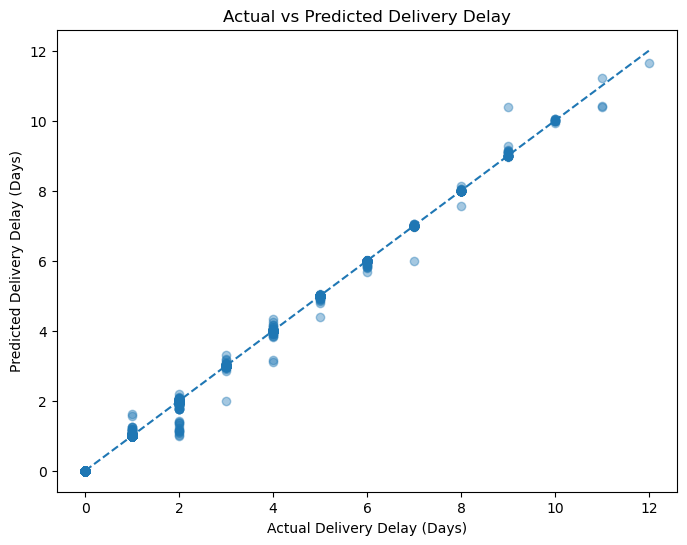

In [16]:
# Actual and predicted values
y_pred = model.predict(X_test)

# Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.4)

plt.xlabel("Actual Delivery Delay (Days)")
plt.ylabel("Predicted Delivery Delay (Days)")
plt.title("Actual vs Predicted Delivery Delay")

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.show()

In [20]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Select logistics-related features
cluster_data = data[
    [
        "shipping_cost_usd",
        "distance_km",
        "warehouse_processing_hours",
        "delivery_attempts",
        "delivery_delay_days"
    ]
].copy()

# Handle missing values
cluster_data = cluster_data.dropna()

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_data)

# Apply K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_data["Cluster"] = kmeans.fit_predict(scaled_data)

# Check cluster counts
print(cluster_data["Cluster"].value_counts().sort_index())

Cluster
0     7375
1    30087
2    12538
Name: count, dtype: int64


In [21]:
# Cluster summary
cluster_summary = cluster_data.groupby("Cluster").mean()

print(cluster_summary)

         shipping_cost_usd  distance_km  warehouse_processing_hours  \
Cluster                                                               
0                95.999620  2162.198454                   14.674861   
1                67.926361  1642.702742                   13.933736   
2               261.132500  4743.079367                   15.406771   

         delivery_attempts  delivery_delay_days  
Cluster                                          
0                 2.038915             1.173831  
1                 1.000000             0.749659  
2                 1.066279             2.619397  


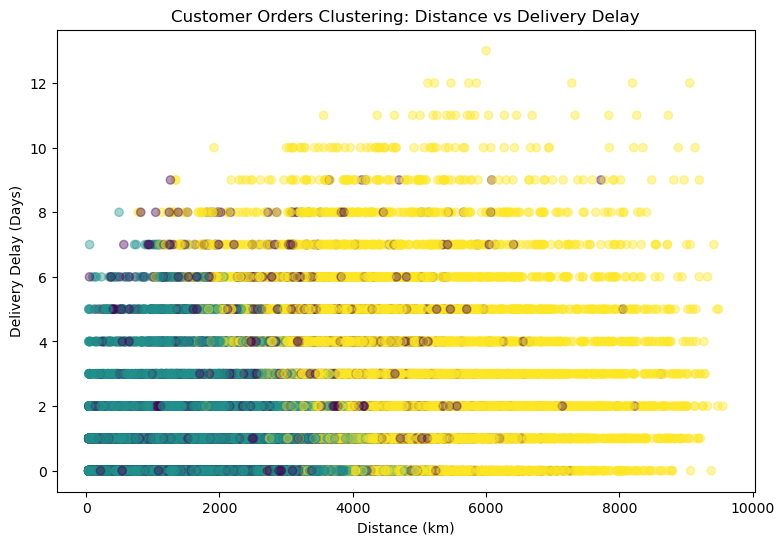

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.scatter(
    cluster_data["distance_km"],
    cluster_data["delivery_delay_days"],
    c=cluster_data["Cluster"],
    alpha=0.4
)

plt.xlabel("Distance (km)")
plt.ylabel("Delivery Delay (Days)")
plt.title("Customer Orders Clustering: Distance vs Delivery Delay")

plt.show()

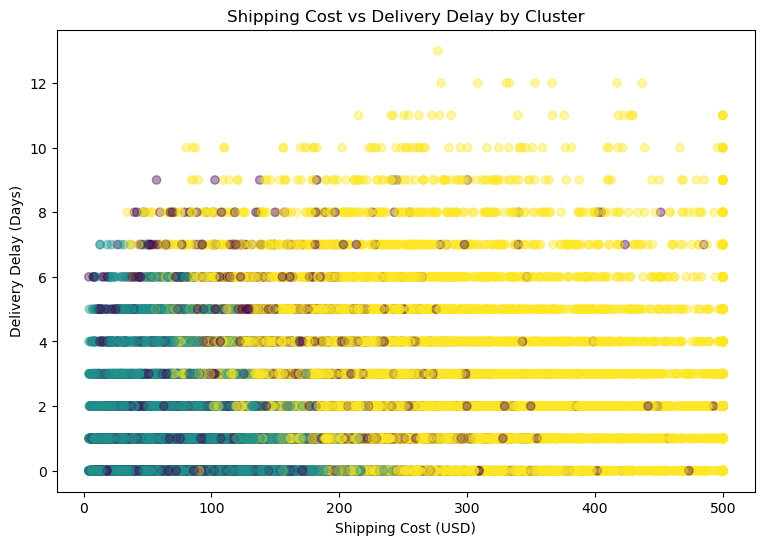

In [23]:
plt.figure(figsize=(9, 6))

plt.scatter(
    cluster_data["shipping_cost_usd"],
    cluster_data["delivery_delay_days"],
    c=cluster_data["Cluster"],
    alpha=0.4
)

plt.xlabel("Shipping Cost (USD)")
plt.ylabel("Delivery Delay (Days)")
plt.title("Shipping Cost vs Delivery Delay by Cluster")

plt.show()

# Optimization

In [25]:
# Optimization-style scenario analysis

delay_targets = [1, 2, 3]

optimization_results = []

for target in delay_targets:
    filtered = cluster_data[
        cluster_data["delivery_delay_days"] <= target
    ]

    optimization_results.append({
        "Maximum Delay Target (Days)": target,
        "Orders": len(filtered),
        "Average Shipping Cost (USD)": filtered["shipping_cost_usd"].mean(),
        "Average Distance (km)": filtered["distance_km"].mean()
    })

optimization_df = pd.DataFrame(optimization_results)

print(optimization_df)

   Maximum Delay Target (Days)  Orders  Average Shipping Cost (USD)  \
0                            1   34084                    98.487559   
1                            2   41161                   106.292151   
2                            3   45045                   111.330445   

   Average Distance (km)  
0            2086.453996  
1            2253.887673  
2            2355.226529  


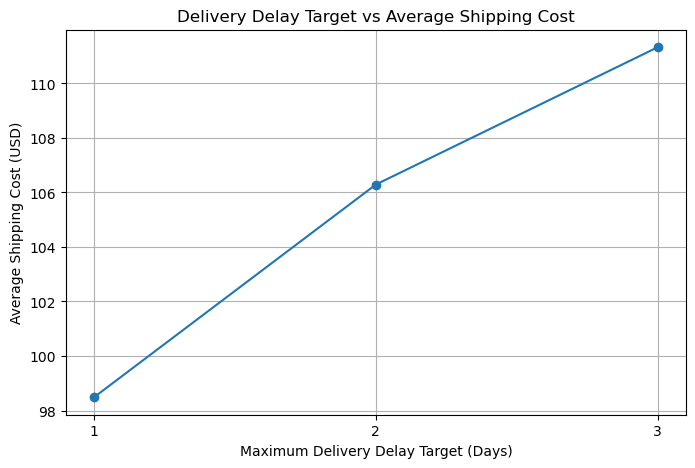

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    optimization_df["Maximum Delay Target (Days)"],
    optimization_df["Average Shipping Cost (USD)"],
    marker="o"
)

plt.xlabel("Maximum Delivery Delay Target (Days)")
plt.ylabel("Average Shipping Cost (USD)")
plt.title("Delivery Delay Target vs Average Shipping Cost")

plt.xticks([1, 2, 3])
plt.grid(True)

plt.show()

# Business Recommendations

Business Recommendations

1. Improve Long-Distance Delivery Planning
   Cluster 2 has the highest average distance (4,743 km) and the highest
   average delivery delay (2.62 days). Long-distance orders should be
   monitored separately and planned using suitable carriers and routes.

2. Reduce Multiple Delivery Attempts
   Cluster 0 has an average of approximately 2 delivery attempts.
   Improving address verification, customer communication and first-attempt
   delivery can help reduce operational effort.

3. Use Delivery-Time Targets
   The optimization analysis shows a trade-off between delivery coverage
   and shipping cost. Different service levels can be defined for different
   customer segments.

4. Monitor Shipping Cost
   Average shipping cost increases as the allowed delivery-delay target
   increases. Shipping costs should therefore be monitored together with
   delivery performance.

5. Use Predictive Analytics
   The regression model can be used as a predictive tool for estimating
   delivery delay and identifying orders that may require operational
   attention.

6. Segment Orders Using Clustering
   The three clusters can be used to create different logistics strategies
   instead of applying the same strategy to every order.

7. Continuous KPI Monitoring
   KPIs such as delivery delay, shipping cost, delivery attempts and
   processing time should be monitored regularly to identify operational
   changes.

# Conclusion

Conclusion

This project analyzed e-commerce delivery and shipping data using a
data-driven logistics approach. The analysis included data preprocessing,
exploratory analysis, KPI analysis, regression, K-Means clustering and
optimization-based scenario analysis.

The regression model showed a strong relationship between the selected
logistics variables and delivery delay. The clustering analysis identified
three distinct logistics groups based on shipping cost, distance,
warehouse processing time, delivery attempts and delivery delay.

The optimization analysis demonstrated a clear trade-off between delivery
time targets, order coverage and shipping cost. A stricter delivery target
covers fewer orders, while a more relaxed target covers more orders but
results in higher average shipping costs.

Overall, the analysis demonstrates how data science techniques can support
logistics planning, delivery performance monitoring, cost analysis and
operational decision-making. These insights can help logistics teams
develop segment-specific strategies and continuously improve supply-chain
efficiency.